## FISTA TV Applied to the Golden Angle Data

This notebook applies FISTA-TV with a non-negativity constraint to golden angle data with 25% of the number of projections as an equidistant scan.

For more info on FISTA: https://tomographicimaging.github.io/CIL/nightly/optimisation/#fista 

FISTA allows us to have a TV regularisation term but we often see faster convergence than with PDHG-TV which is why we try it out here!

In [3]:
import os
from matplotlib import pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

from cil.utilities.display import show2D
from cil.processors import Slicer
from cil.plugins.astra import ProjectionOperator
from cil.optimisation.functions import IndicatorBox
from cil.optimisation.utilities.callbacks import ProgressCallback, EarlyStoppingObjectiveValue
from cil.io import NEXUSDataWriter

from cil.optimisation.functions import LeastSquares
from cil.optimisation.algorithms import FISTA

from data_io.io import read_mantid_imaging_data
from recon.weighted_fbp import run_weighted_fbp_parallel
from utils.lego_man import calculate_metrics, make_bar_plots
from cil.plugins.ccpi_regularisation.functions import FGP_TV
from cil.utilities.display import show1D

In [4]:
base_path = "/home/lhe97136/Data/Lego GR Investigation/Data for Release/preprocessed_data/"
gr_full = read_mantid_imaging_data(os.path.join(base_path, "Golden_Ratio"), pixel_size=100*10**-4)
equi_full = read_mantid_imaging_data(os.path.join(base_path, "Equidistant"), pixel_size=100*10**-4)

In [5]:
equi_full_slice = equi_full.get_slice(vertical=317)
equi_full_slice.reorder('astra')
equi_full_recon = run_weighted_fbp_parallel(equi_full_slice)

Make slices:

In [6]:
gr_scales = [0.25, 0.5, 0.75]
gr_slices = {gr_scale: Slicer(roi={'angle': (0, 457 * gr_scale), 'vertical': (317, 318)})(gr_full) for gr_scale in gr_scales}
gr_slices_fbp = {gr_scale: run_weighted_fbp_parallel(gr_slice) for gr_scale, gr_slice in gr_slices.items()}

### Setup the FISTA algorithm

We set up the FISTA Algorithm with Total Variation Regularisation and a non-negativity constraint.
We set it up with a range of alpha values.
Note: to begin with we performed a wider sweep of alpha values:
[1e-6, 1e-4, 1e-2, 1] to get an idea of where to do a finer sweep of alphas.

In [7]:
alphas = [1e-3, 2.5e-3, 5e-3, 7.5e-3,1e-2, 2.5e-2]
fista_nn_algos = {alpha: None for alpha in alphas}
# --- build unconstrained fista algorithms ---
for alpha in alphas:
    gr_scale=0.25
    gr_slice = gr_slices[gr_scale]
    A = ProjectionOperator(gr_slice.geometry.get_ImageGeometry(), gr_slice.geometry)
    b = gr_slice
    F = LeastSquares(A, b)
    G = IndicatorBox(lower=0.0)
    ig = gr_slice.geometry.get_ImageGeometry()
    GTV = alpha*FGP_TV(device='gpu', nonnegativity=True) 
    initial = ig.allocate(0.0)
    myFISTANN = FISTA(f=F, 
                g=GTV,  initial=initial,
                update_objective_interval = 10)

    fista_nn_algos[alpha] = myFISTANN

We run each algorithm for a maximum of 1000 iterations but use a stopping rule based on change in objective value to determine whether convergence has been reached. If the objective value changes by less than our threshold of 1e-5 then the algorithm will stop iterating:

In [8]:

iteration_nums = 1000

for alpha, fista in fista_nn_algos.items():
    fista.run(iteration_nums, callbacks=[ProgressCallback(), EarlyStoppingObjectiveValue(threshold=1e-5)])

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

First we'll look at a ROI where we can see both the lego man head and the lead container.
Then we'll zoom in on separate ROIs of the head and lead.

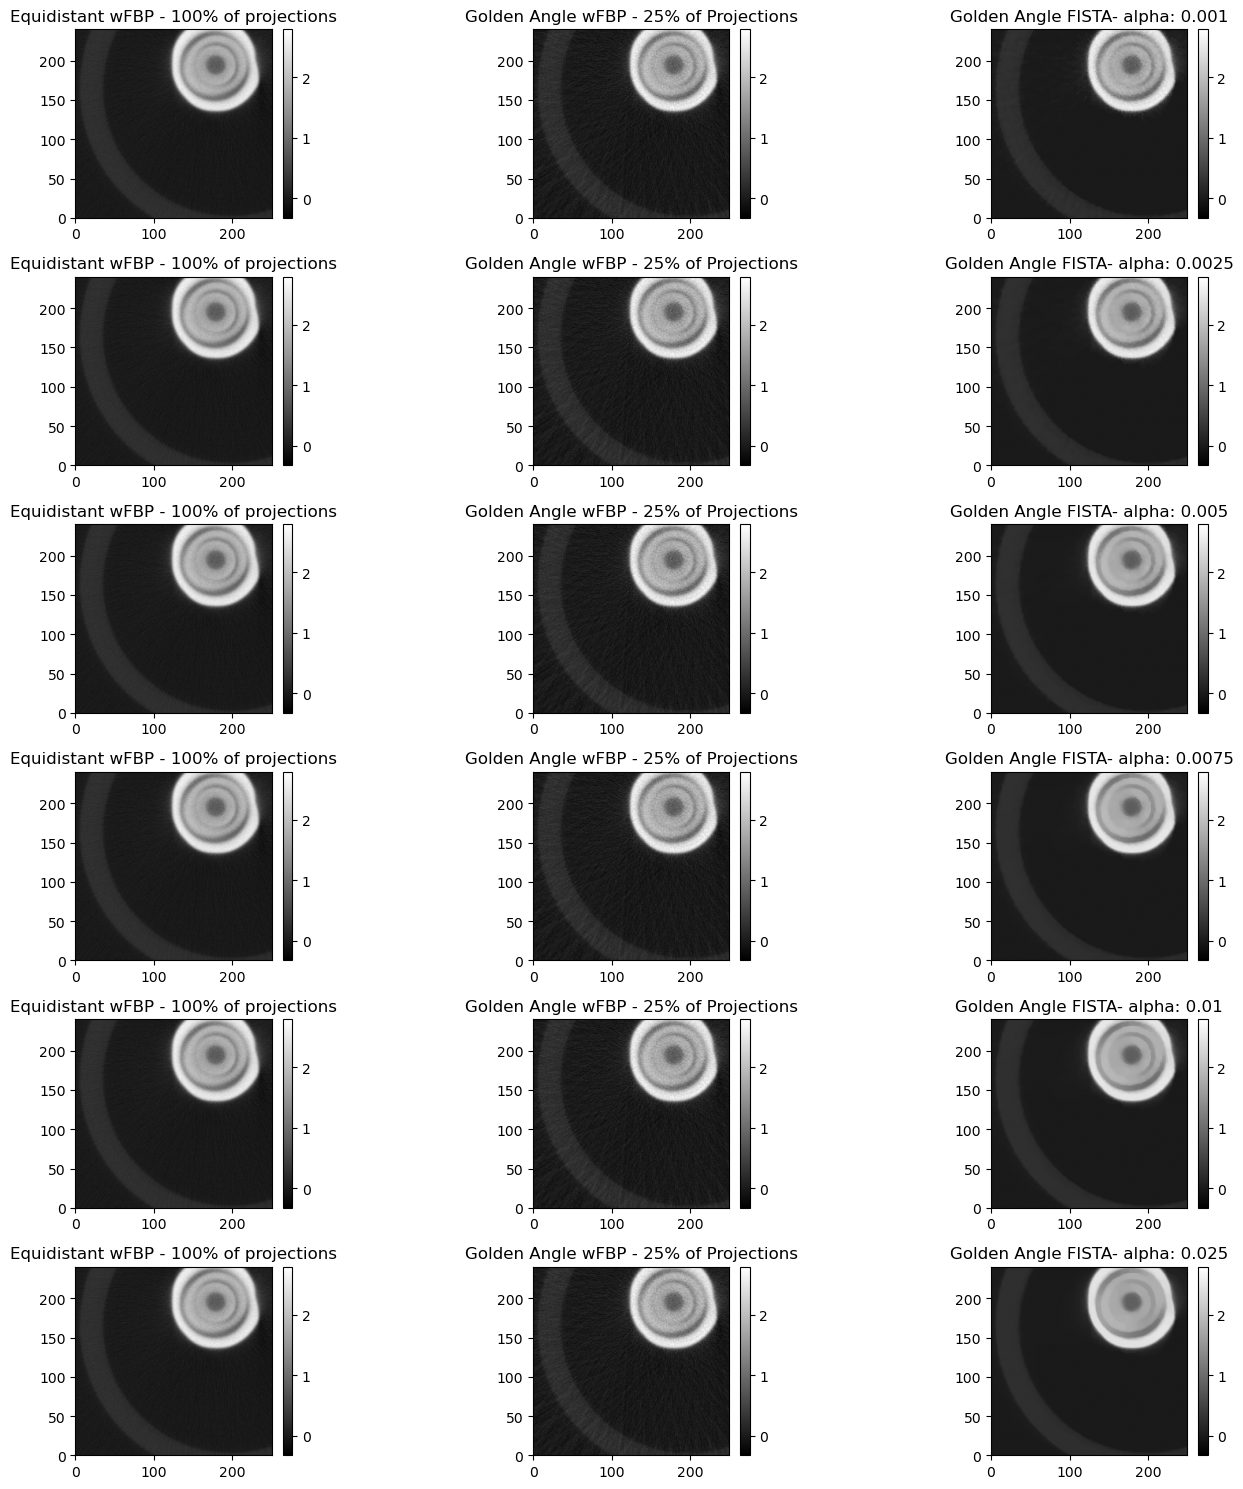

In [9]:
gr_scales=[0.25]
fista_titles = [f"Golden Angle FISTA- alpha: {alpha}" for alpha in alphas]
fista_results = [fista_nn_algos[alpha].solution for alpha in alphas]
fbp_titles = [f"Golden Angle wFBP - {gr_scale*100:.0f}% of Projections" for alpha in alphas]
fbp_results = [gr_slices_fbp[gr_scale]]*len(alphas)

images = []
titles = []
zoomed_equi_recon = equi_full_recon
for alpha, fista_img, fista_title, fbp_img, fbp_title in zip(alphas, fista_results, fista_titles, fbp_results, fbp_titles):
    images.extend([zoomed_equi_recon,fbp_img, fista_img])
    titles.extend([f"Equidistant wFBP - 100% of projections", fbp_title, fista_title])

vmin = min(img.min() for img in images)
vmax = max(img.max() for img in images)

show2D([x.array[110:350, 100:350] for x in images], title=titles, cmap='gray', fix_range=(vmin, vmax), num_cols=3)

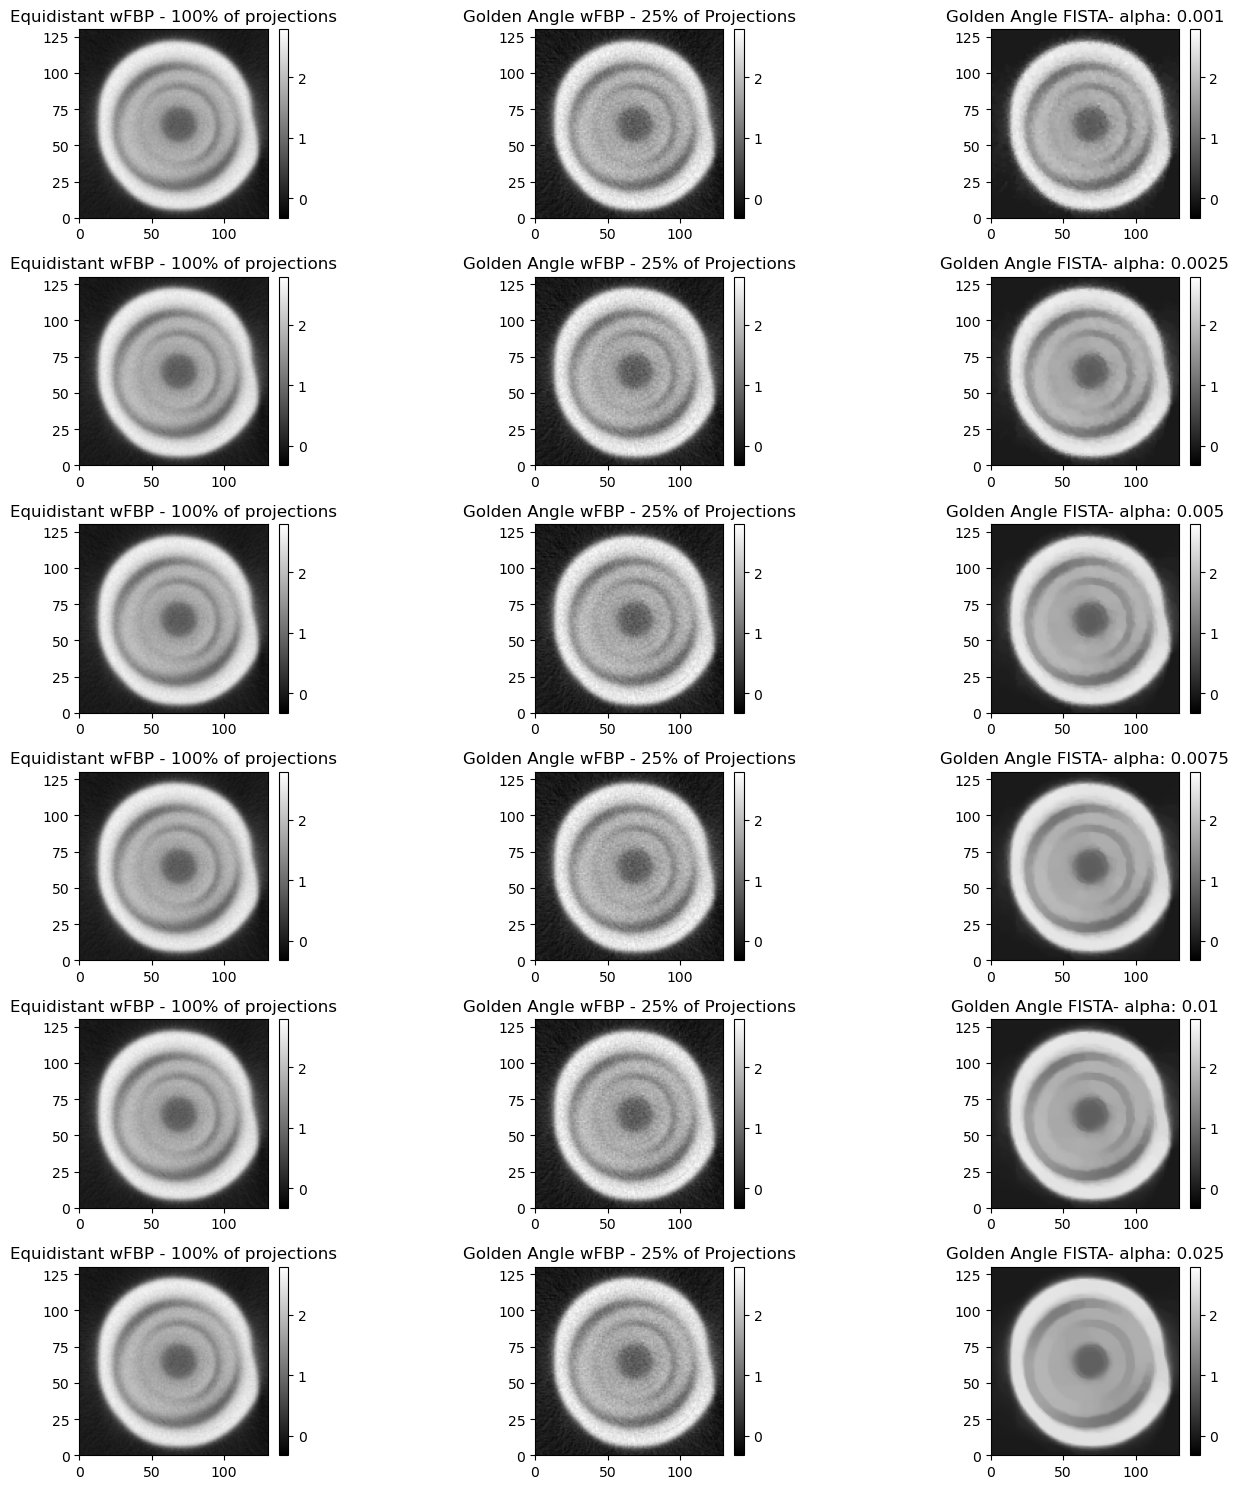

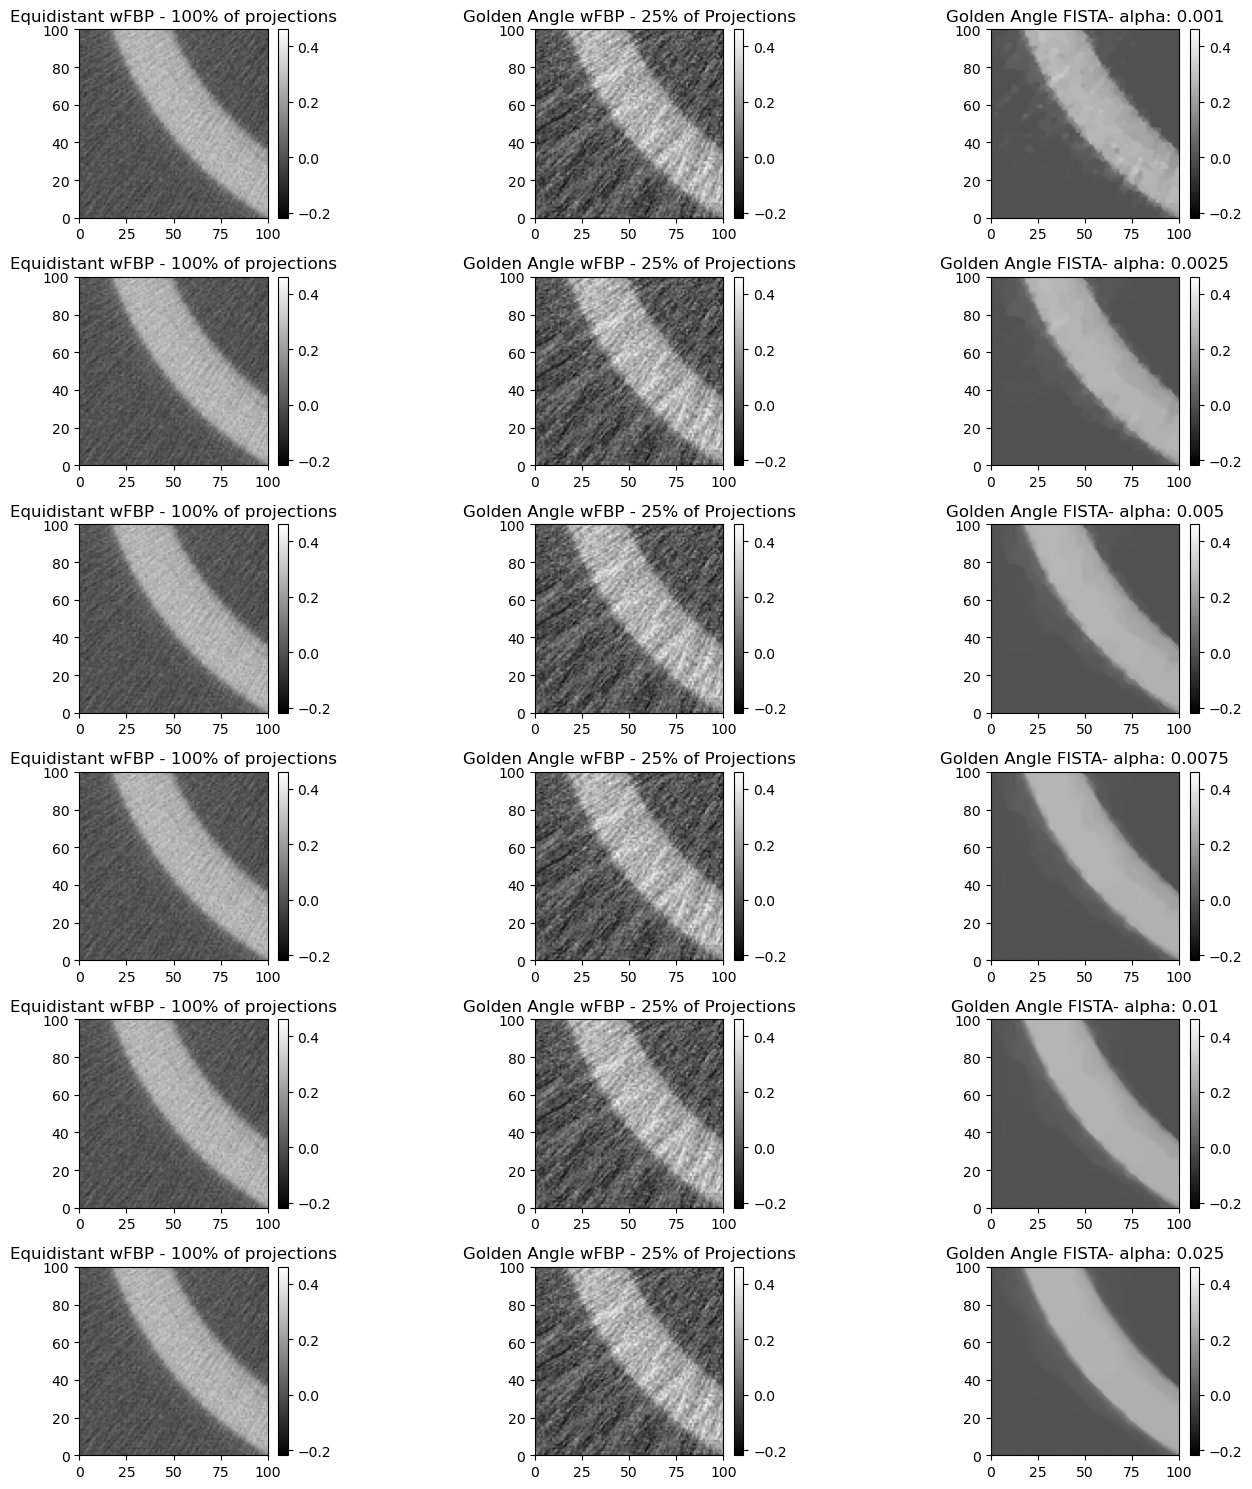

In [10]:
show2D([x.array[240:370, 210:340] for x in images], title=titles, cmap='gray', fix_range=(vmin, vmax), num_cols=3)

data_lead = [x.array[110:210, 100:200] for x in images]
mn = min(x.min() for x in data_lead)
mx = max(x.max() for x in data_lead)
show2D(data_lead, title=titles, cmap='gray', fix_range=(mn, mx), num_cols=3)

With alpha=0.001 its clear we still have quite a bit of noise in the images.
We see the most smoothing in the lead region with 0.025, however, we see material being put in the gaps between the layers of the lego man's head, indicating we have over-regularised. We need to choose a value somewhere in between these.

Lets look at the line profiles. Here we only compare to the Equidistant FBP, not the wFBP of the 25% Golden Angle. This is because we know from notebook 01 that the wFBP of the 25% Golden Angle is much noiser and we want to be able to see the FISTA results more clearly:


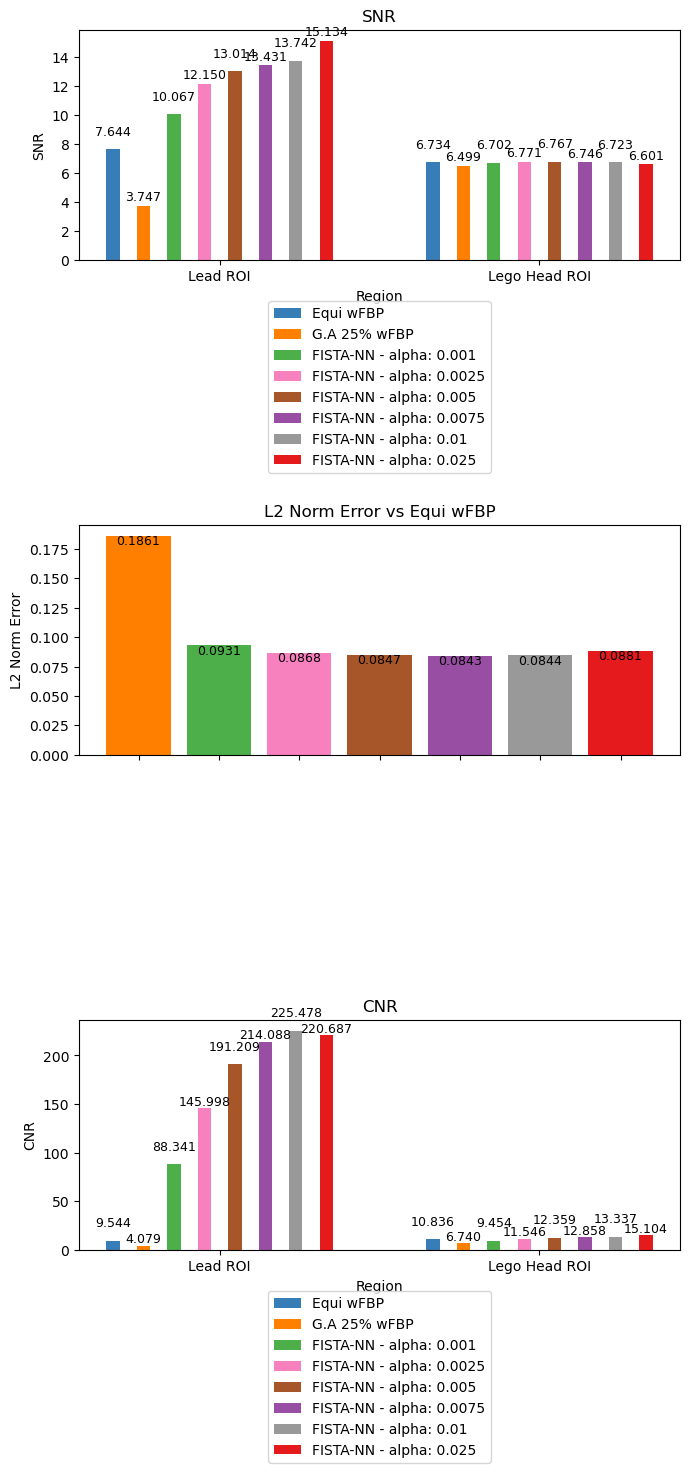

In [11]:

show1d_slicer_lead = Slicer(roi={'horizontal_x':(50,200)})
show1d_slicer_head = Slicer(roi={'horizontal_x':(200,350)})

fista_results_list = [gr_slices_fbp[gr_scale]] + [fista_nn_algos[alpha].solution for alpha in alphas]
data = fista_results_list
_titles= ['Equi wFBP', 'G.A 25% wFBP'] + [f"FISTA-NN - alpha: {alpha}" for alpha in alphas]
l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner  = calculate_metrics(equi_full_recon, data)
make_bar_plots(l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner, _titles, orientation='vertical')


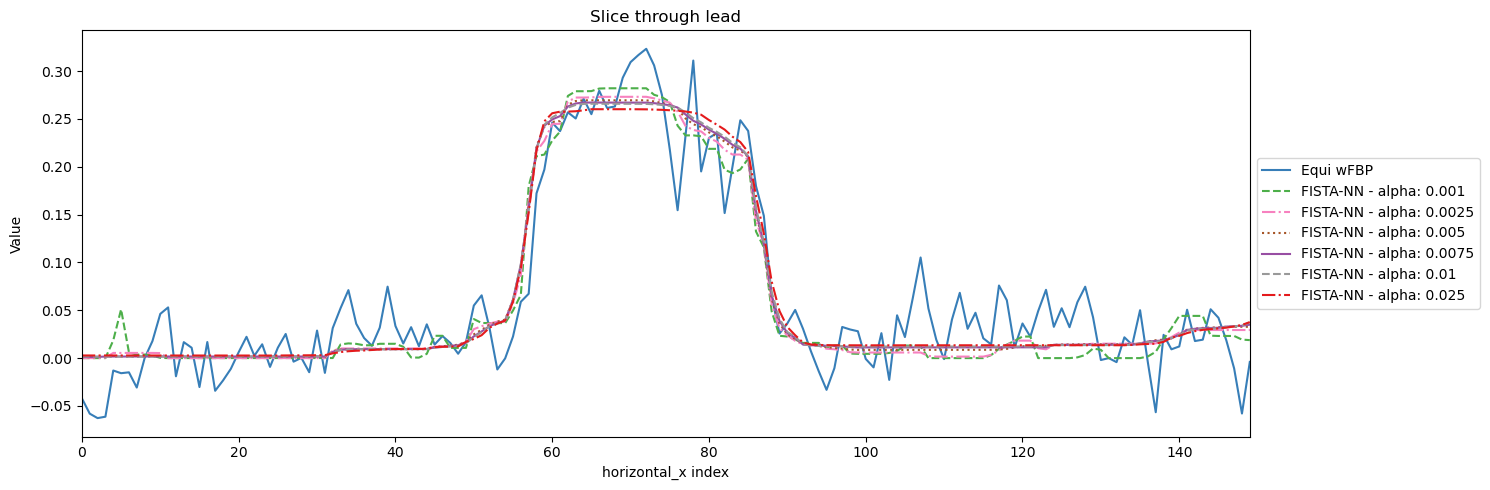

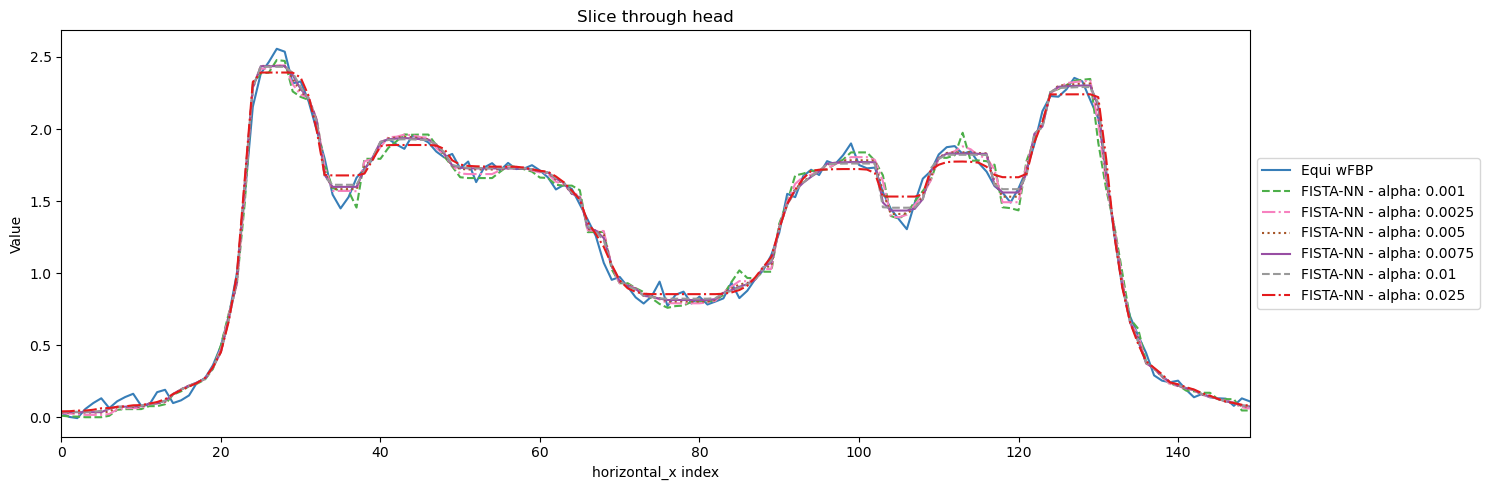

In [12]:
data = [equi_full_recon] + fista_results_list
colors = ['#377eb8', '#4daf4a',
                    '#f781bf', '#a65628', '#984ea3',
                    '#999999', '#e41a1c', '#dede00']
show1D([show1d_slicer_lead(x) for x in [data[0]]+ data[2:]], slice_list=[('horizontal_y', 300)], dataset_labels=[_titles[0]]+ _titles[2:], title="Slice through lead", size=(15,5), line_colours=colors)
show1D([show1d_slicer_head(x) for x in [data[0]]+ data[2:]], slice_list=[('horizontal_y', 300)], dataset_labels=[_titles[0]]+ _titles[2:], title="Slice through head", size=(15,5), line_colours=colors)


The metrics show we see:
- Increased SNR in the lead ROI compared to full equidistant and 25% golden ratio scans with wFBP. Increasing as alpha increases. This is the same trend as we saw by eye in the lead region.
- Similar SNR in the lego head region across the alpha values, although the highest alpha has the lowest SNR in this region out of them all.
- The lowest L2Norm errors between the FISTA reconstruction and FBP of Equidistant full scan is seen with alphas [0.005, 0.0075,0.01]
- Increased CNR as alpha increases in the lego head ROI - here the metric looks at the signal in the lego vs the air in the centre of the head, so unfortunately doesn't capture that the air boundaries between layers are getting reduced as we see in the line profile.
- Increased CNR in the lead as alpha increases, except a reduction with the highest alpha.

In all cases, we see smoothing of the noise.

Let's pick alpha=0.005. It doesn't score highest on the metrics but preserves the line profiles well and the images look good!

We used a stopping rule to make sure the algorithm had converged for each value of alpha.
For our chosen alpha lets take a look at the convergence plot to check this!

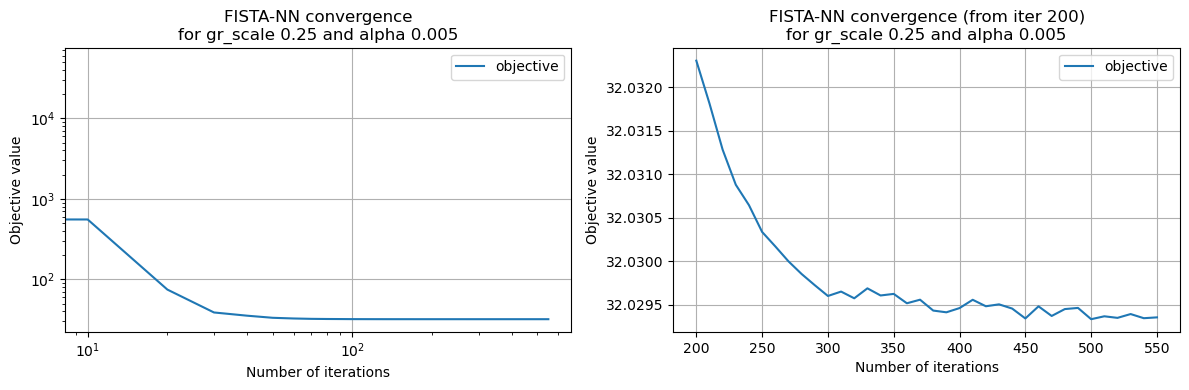

In [13]:
fista_algo = fista_nn_algos[5e-3]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(fista_algo.iterations, fista_algo.objective)
axes[0].legend(['objective'])
axes[0].grid()
axes[0].set_xlabel('Number of iterations')
axes[0].set_ylabel('Objective value')
axes[0].set_title(f'FISTA-NN convergence\nfor gr_scale {gr_scale} and alpha {5e-3}')

axes[1].plot(fista_algo.iterations[20:], fista_algo.objective[20:])
axes[1].legend(['objective'])
axes[1].grid()
axes[1].set_xlabel('Number of iterations')
axes[1].set_ylabel('Objective value')
axes[1].set_title(f'FISTA-NN convergence (from iter 200)\nfor gr_scale {gr_scale} and alpha {5e-3}')

plt.tight_layout()
plt.show()

In [14]:
output_folder = "outputs"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
if not os.path.exists(os.path.join(output_folder, "golden_angle_lego")):
    os.makedirs(os.path.join(output_folder, "golden_angle_lego"))

nexus_writer = NEXUSDataWriter(data = fista_nn_algos[5e-3].solution, file_name = os.path.join(output_folder, "golden_angle_lego", "fista_25_percent.nxs"))
nexus_writer.write()